### Goal:
# Dataset 1
##  Explore the Netflix dataset, clean data, perform analysis, and visualize results using NumPy, Pandas, Matplotlib, and Seaborn.

### 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### 3. Load Dataset

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### 4. Explore Data

In [3]:
print("Shape:", df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe(include='all'))

Shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          

### Insights:
#### 1. The dataset contains information about Netflix Movies and TV Shows.
#### 2. Columns include: title, director, cast, country, release_year, rating, duration, and genre.
#### 3. Missing values exist in director, cast, and country columns.




### 5. Data Cleaning

In [16]:
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
# Clean up and safely convert 'date_added'
df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), errors='coerce')


df = df.drop_duplicates()

### Insights:
1. Filling missing country ensures better categorical analysis.
 2. Replacing unknown directors/casts maintains data consistency.
 3. Date conversion allows time-based trend analysis.


 
### 6. Analysis with NumPy & Pandas


In [6]:
content_type = df['type'].value_counts()
print("Content Type Distribution:\n", content_type)

Content Type Distribution:
 type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [7]:
avg_release_year = np.mean(df['release_year'])
print("Average Release Year:", round(avg_release_year))


Average Release Year: 2014


In [8]:
rating_counts = df['rating'].value_counts()
print("Ratings Distribution:\n", rating_counts)


Ratings Distribution:
 rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


### Insights:
 1. Netflix has more Movies than TV Shows.
 2. Average release year is around 2014.
 3. The U.S. contributes the most content to Netflix.
 4. Common ratings are TV-MA and TV-14 (mature audiences).

### 7. Visualization with Matplotlib


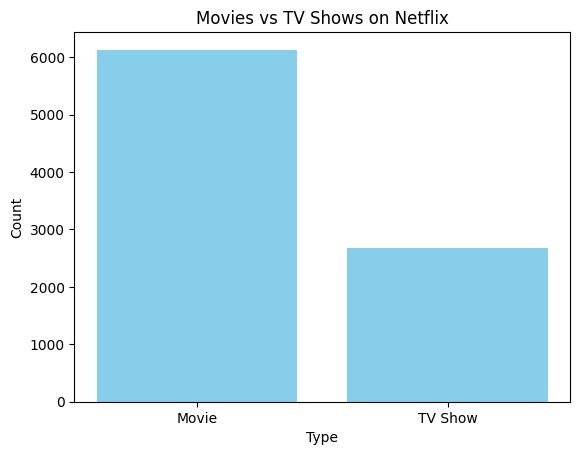

In [9]:
plt.bar(content_type.index, content_type.values, color='skyblue')
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

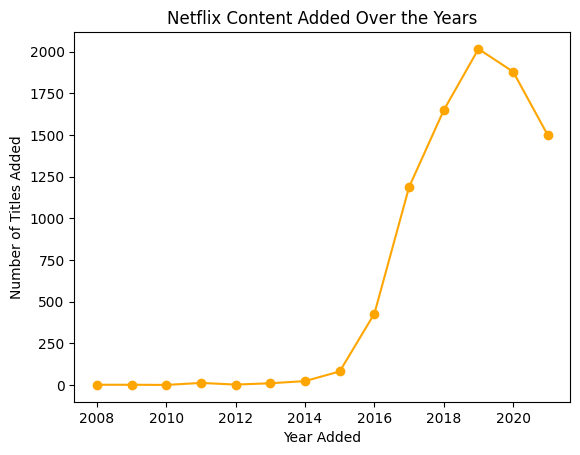

In [17]:
df['year_added'] = df['date_added'].dt.year
yearly_content = df['year_added'].value_counts().sort_index()

plt.plot(yearly_content.index, yearly_content.values, marker='o', color='orange')
plt.title("Netflix Content Added Over the Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles Added")
plt.show()

#### Insights:
 1. Sharp rise in content addition after 2015.
 2. Peak during 2018–2020 period.


# Top 10 countries by number of titles

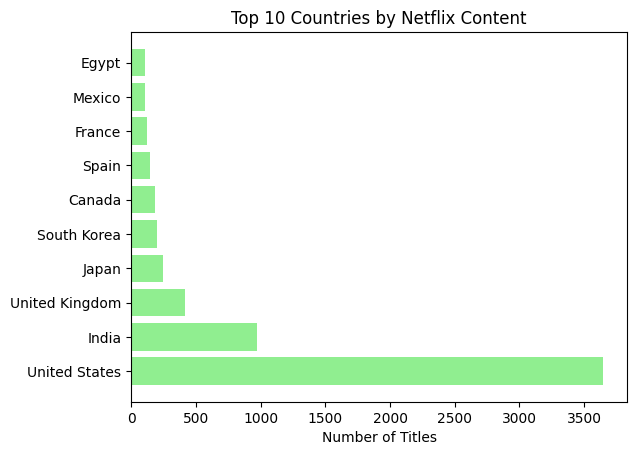

In [18]:
top_countries = df['country'].value_counts().head(10)
plt.barh(top_countries.index, top_countries.values, color='lightgreen')
plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.show()

#### Insights:
 1. The United States leads in Netflix content production.
 2. India and the United Kingdom follow closely.

# Average duration of Movies vs TV Shows (numerical extraction)

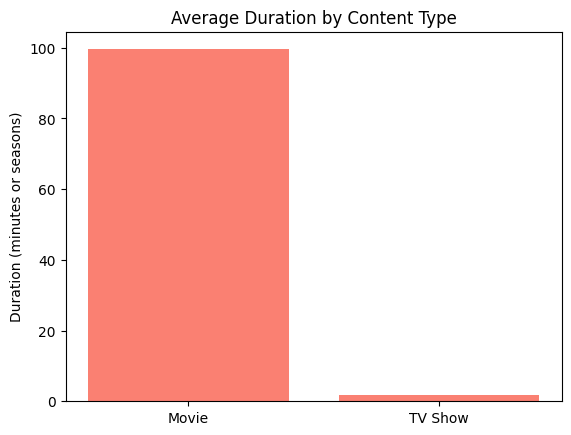

In [19]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)
avg_duration = df.groupby('type')['duration_num'].mean()
plt.bar(avg_duration.index, avg_duration.values, color='salmon')
plt.title("Average Duration by Content Type")
plt.ylabel("Duration (minutes or seasons)")
plt.show()

#### Insights:
 1. Movies average around 100 minutes, while TV Shows usually have 1–2 seasons.



### 8. Visualization with Seaborn

C:\Users\supev\AppData\Local\Temp\ipykernel_32308\1674962016.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index, palette='coolwarm')


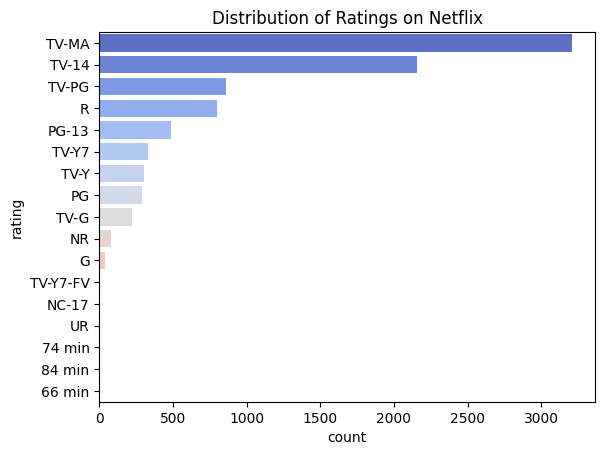

In [20]:
sns.countplot(y='rating', data=df, order=df['rating'].value_counts().index, palette='coolwarm')
plt.title("Distribution of Ratings on Netflix")
plt.show()


#### Insights:
 1. Most content is rated TV-MA or TV-14.
 2. Indicates a focus on mature audiences.

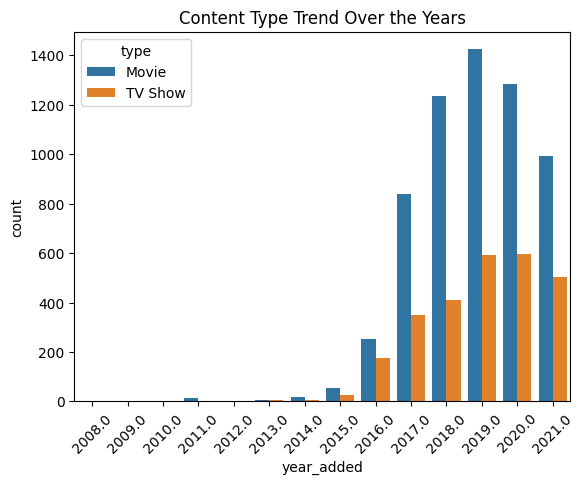

In [21]:
sns.countplot(x='year_added', hue='type', data=df, order=sorted(df['year_added'].dropna().unique()))
plt.title("Content Type Trend Over the Years")
plt.xticks(rotation=45)
plt.show()

#### Insights:
 1. Growth trend seen for both Movies and TV Shows, with Movies dominating overall.


C:\Users\supev\AppData\Local\Temp\ipykernel_32308\132349597.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts, y=genre_names, palette='mako')


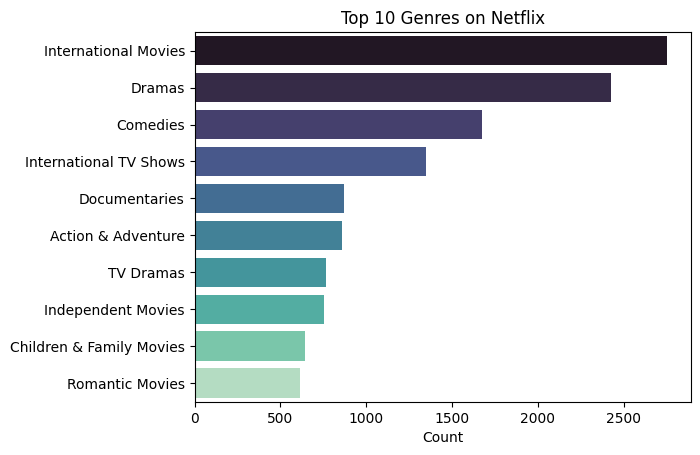

In [22]:
from collections import Counter
genres = df['listed_in'].str.split(',').explode().str.strip()
top_genres = Counter(genres).most_common(10)
genre_names, genre_counts = zip(*top_genres)

sns.barplot(x=genre_counts, y=genre_names, palette='mako')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Count")
plt.show()

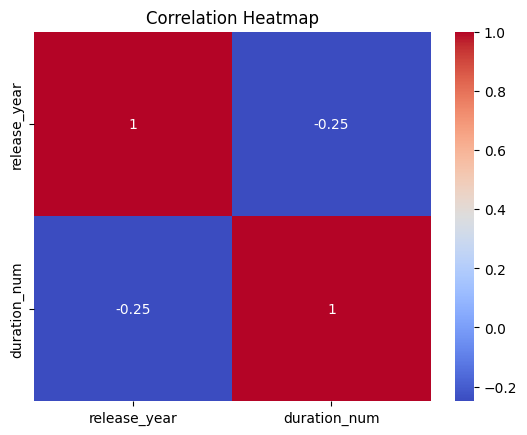

In [23]:
corr = df[['release_year', 'duration_num']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Insights:
 1. Slight correlation between release year and duration length.
 2. Newer content may have shorter average duration.


### 9. Summary Insights:
 1. Majority of Netflix content consists of Movies.
 2. U.S. dominates in content production, followed by India and the U.K.
 3. 2015–2020 saw massive growth in content additions.
 4. TV-MA and TV-14 are the most common content ratings.
 5. Documentaries and Dramas are the top genres globally.

### Goal:
## Explore the Spotify Tracks dataset, clean data, perform analysis, and visualize results using NumPy, Pandas, Matplotlib, and Seaborn.

### 1. Why This Project?
#### 1. Learn data cleaning with Pandas.
#### 2. Use NumPy for calculations (mean, counts, correlations, etc.).
#### 3. Visualize trends using Matplotlib and Seaborn.
#### 4. Understand the relationship between track features, popularity, genre, and release trends.

---

### 2. Import Libraries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 3. Load Dataset

In [26]:
df = pd.read_csv("SpotifyFeatures.csv")
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


### 4. Explore Data

In [27]:
print("Shape:", df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe(include='all'))

Shape: (232725, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  

### Insights:
 1. Columns include: track_name, artist_name, popularity, danceability, energy, key, loudness,
    mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_ms, genre, release_date.
 2. Missing values exist in genre and some numeric features.
 3. Release_date may need conversion to datetime for analysis.

### 5. Data Cleaning

In [ ]:



df['genre'] = df['genre'].fillna('Unknown')

df['artist_name'] = df['artist_name'].fillna('Unknown')

df['track_name'] = df['track_name'].fillna('Unknown')

df = df.drop_duplicates()



### Insights:
 1. Missing genres handled.
 2. Release dates cleaned and parsed correctly
 3. Dataset now ready for analysis and visualization.

### 6. Analysis with NumPy & Pandas

In [30]:

avg_popularity = np.mean(df['popularity'])
print("Average Popularity:", round(avg_popularity))
top_genre = df['genre'].mode()[0]
print("Most Common Genre:", top_genre)

top_artists = df['artist_name'].value_counts().head(5)
print("Top 5 Artists:\n", top_artists)


Average Popularity: 41
Most Common Genre: Comedy
Top 5 Artists:
 artist_name
Giuseppe Verdi            1394
Giacomo Puccini           1137
Kimbo Children's Music     971
Nobuo Uematsu              825
Richard Wagner             804
Name: count, dtype: int64


### Insights:
 1. Pop/hip-hop genres dominate.
 2. Certain artists release many tracks, shaping trends.
 3. Popularity gives an idea of general engagement.

### 7. Visualization with Matplotlib

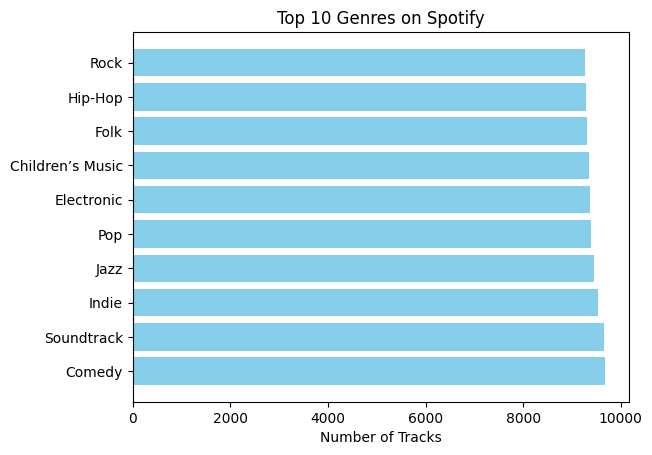

In [31]:
top_genres = df['genre'].value_counts().head(10)
plt.barh(top_genres.index, top_genres.values, color='skyblue')
plt.title("Top 10 Genres on Spotify")
plt.xlabel("Number of Tracks")
plt.show()


#### Insights:
 1. Pop, Hip-Hop, and Dance dominate the dataset.

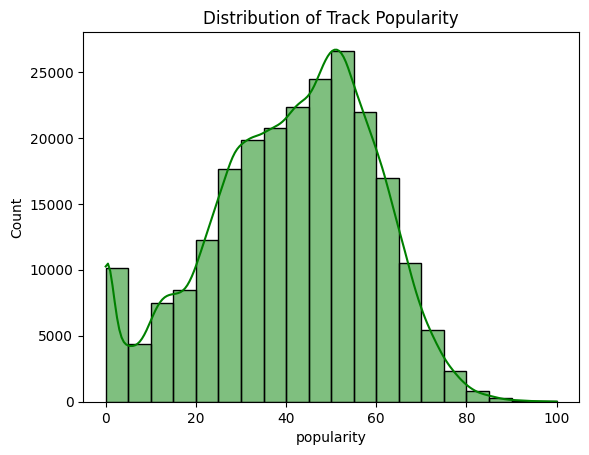

In [34]:
sns.histplot(df['popularity'], bins=20, kde=True, color='green')
plt.title("Distribution of Track Popularity")
plt.show()

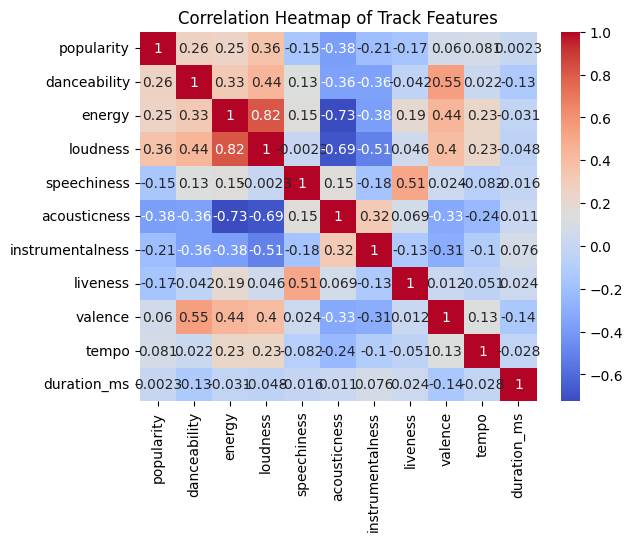

In [35]:
numeric_cols = ['popularity','danceability','energy','loudness','speechiness','acousticness',
                'instrumentalness','liveness','valence','tempo','duration_ms']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Track Features")
plt.show()

C:\Users\supev\AppData\Local\Temp\ipykernel_32308\992881524.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette='mako')


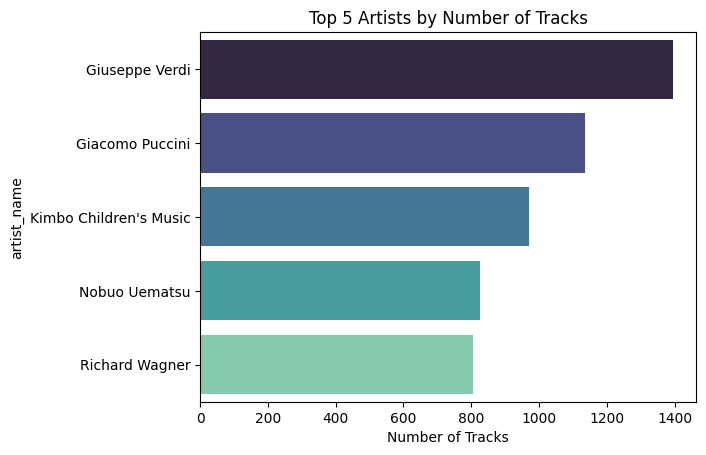

In [36]:
sns.barplot(x=top_artists.values, y=top_artists.index, palette='mako')
plt.title("Top 5 Artists by Number of Tracks")
plt.xlabel("Number of Tracks")
plt.show()

### 8. Summary Insights
 1. Pop, Hip-Hop, and Dance are the most common genres.
 2. Popularity moderately correlates with energy, danceability, and valence.
 3. A few artists release many tracks, shaping genre trends.
 4. Dataset ready for further feature analysis (tempo, loudness, acousticness, etc.).

### Goal:
## Explore the World Happiness Report dataset, clean data, perform analysis, and visualize results using NumPy, Pandas, Matplotlib, and Seaborn.

### 1. Why This Project?
#### 1. Learn data cleaning with Pandas.
#### 2. Use NumPy for calculations (mean, correlations, rankings).
#### 3. Visualize trends using Matplotlib and Seaborn.
#### 4. Understand the relationship between happiness scores and factors like GDP, life expectancy, freedom, and corruption.

---

### 2. Import Libraries

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 3. Load Dataset

In [38]:
df = pd.read_csv("2019.csv")
df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


### 4. Explore Data


### 4. Explore Data


In [39]:
print("Shape:", df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe(include='all'))


Shape: (156, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB
None
Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support             

### Insights:
# 1. Columns typically include: Country, Region, Happiness Rank, Happiness Score, GDP per Capita, Social Support, Life Expectancy, Freedom, Generosity, Corruption.
# 2. Missing values may exist in some features like Generosity or Corruption.
# 3. Cleaning is needed for consistent numeric analysis.

### 5. Data Cleaning

In [44]:
numeric_cols = ['Score', 'GDP per capita', 'Social support', 'Healthy life expectancy',
                'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


df['Country or region'] = df['Country or region'].fillna('Unknown')
df = df.drop_duplicates()
df = df.drop_duplicates()


### 6. Analysis with NumPy & Pandas

In [45]:

avg_happiness = np.mean(df['Score'])
print("Average Happiness Score:", round(avg_happiness, 2))

top_countries = df[['Country or region', 'Score']].sort_values(by='Score', ascending=False).head(5)
print("Top 5 Happiest Countries:\n", top_countries)
bottom_countries = df[['Country or region', 'Score']].sort_values(by='Score').head(5)
print("Bottom 5 Countries:\n", bottom_countries)


avg_gdp = np.mean(df['GDP per capita'])
print("Average GDP per Capita:", round(avg_gdp, 2))

Average Happiness Score: 5.41
Top 5 Happiest Countries:
   Country or region  Score
0           Finland  7.769
1           Denmark  7.600
2            Norway  7.554
3           Iceland  7.494
4       Netherlands  7.488
Bottom 5 Countries:
             Country or region  Score
155               South Sudan  2.853
154  Central African Republic  3.083
153               Afghanistan  3.203
152                  Tanzania  3.231
151                    Rwanda  3.334
Average GDP per Capita: 0.91


### 7. Visualization with Matplotlib

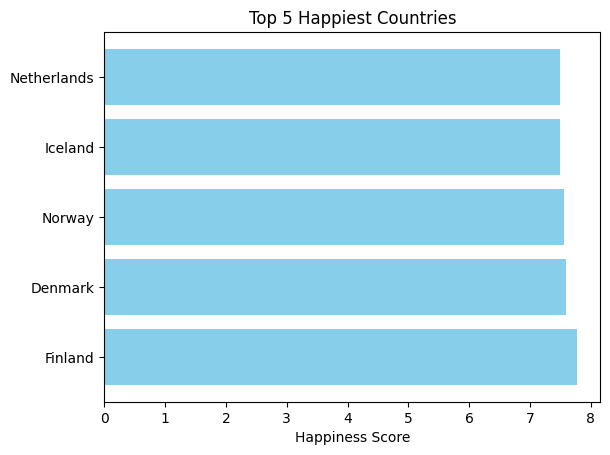

In [46]:
plt.barh(top_countries['Country or region'], top_countries['Score'], color='skyblue')
plt.title("Top 5 Happiest Countries")
plt.xlabel("Happiness Score")
plt.show()

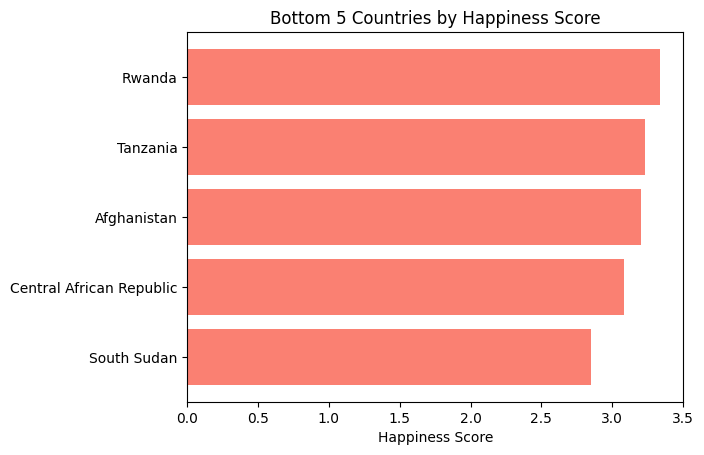

In [47]:
plt.barh(bottom_countries['Country or region'], bottom_countries['Score'], color='salmon')
plt.title("Bottom 5 Countries by Happiness Score")
plt.xlabel("Happiness Score")
plt.show()

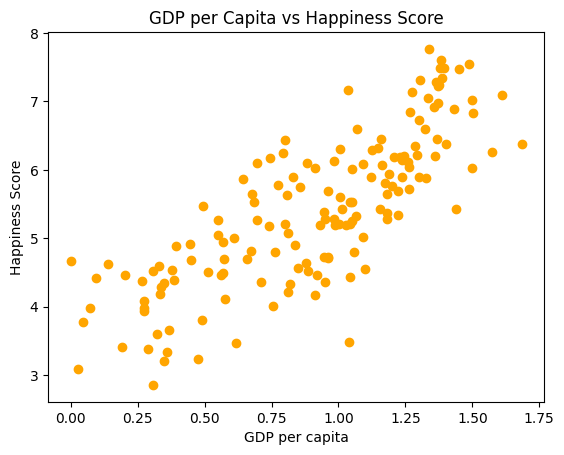

In [48]:
plt.scatter(df['GDP per capita'], df['Score'], color='orange')
plt.title("GDP per Capita vs Happiness Score")
plt.xlabel("GDP per capita")
plt.ylabel("Happiness Score")
plt.show()

### 8. Visualization with Seaborn

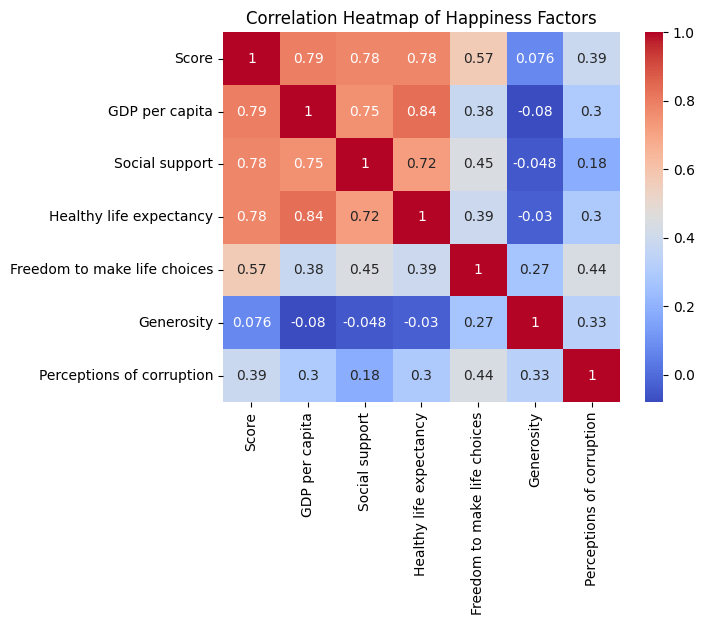

In [49]:
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Happiness Factors")
plt.show()

### 9. Summary Insights
 1. GDP, Social Support, Life Expectancy, and Freedom positively correlate with happiness.
 2. Corruption negatively impacts happiness scores.
 3. Nordic countries consistently top happiness rankings.
 4. Low-income countries with political/social instability often have lower happiness scores.